# Hipótesis, KPIs y Visualizaciones para Power BI

Este notebook está basado en [docs/hipotesis_y_kpis.md](../docs/hipotesis_y_kpis.md) y trabaja principalmente sobre el warehouse SQLite del proyecto.

El objetivo es:
- Calcular métricas base para las 4 hipótesis.
- Generar tablas agregadas que puedan reutilizarse en Power BI.
- Proponer gráficas concretas para el dashboard del negocio.

## 1. Contexto de negocio

Las hipótesis principales analizan operación, rentabilidad, satisfacción y efectividad promocional. Los KPIs asociados permiten seguir el desempeño del negocio con foco en el warehouse.

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DW_PATH = BASE_DIR / 'data' / 'warehouse' / 'food_delivery_dw.sqlite'
DW_PATH

WindowsPath('c:/Users/usuario/Documents/01_Principales/Trabajo/Universidad/AnalisisDatos/food-delivery/data/warehouse/food_delivery_dw.sqlite')

In [2]:
def run_query(query: str) -> pd.DataFrame:
    with sqlite3.connect(DW_PATH) as conn:
        return pd.read_sql_query(query, conn)

def sql_value(query: str):
    return run_query(query).iloc[0, 0]

## 2. Estructura del warehouse

Antes de analizar hipótesis, revisamos tablas disponibles y una muestra de la tabla de hechos.

In [3]:
tables = run_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
tables

,name
0,dim_customer_segment
1,dim_date
2,dim_delivery_conditions
3,dim_order_status
4,fact_delivery_orders


In [4]:
fact_sample = run_query("SELECT * FROM fact_delivery_orders LIMIT 5")
fact_sample

,date_id,customer_segment_id,delivery_conditions_id,order_status_id,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,delivery_time_minutes,preparation_time_minutes,customer_rating,delivery_efficiency_score
0,1,1,1,1,100.000000,14.592603,22.969358,19.940540,111.563782,76.0,23.0,2.9,1.467944
1,2,2,2,2,100.000000,4.391720,4.434405,16.101950,116.059265,34.0,16.0,3.4,3.413508
2,3,3,3,3,100.000000,9.006407,14.979692,17.681454,111.708168,152.0,41.0,3.7,0.734922
3,4,4,4,3,145.113449,11.407034,14.813044,11.593912,153.301346,93.0,9.0,4.1,1.648402
4,5,5,5,4,100.000000,11.572232,13.716308,13.272883,111.128807,141.0,49.0,4.6,0.788148


## 3. KPIs principales

Estos KPIs resumen el comportamiento de la operación y se conectan directamente con las hipótesis definidas en el documento base.

In [5]:
kpi_df = pd.DataFrame([
    {
        'KPI': 'ADT - Tiempo promedio de entrega',
        'Valor': sql_value("SELECT AVG(delivery_time_minutes) FROM fact_delivery_orders"),
        'Unidad': 'minutos'
    },
    {
        'KPI': 'CSAT - Satisfacción promedio',
        'Valor': sql_value("SELECT AVG(customer_rating) FROM fact_delivery_orders"),
        'Unidad': '1-5 estrellas'
    },
    {
        'KPI': 'OCR - Tasa de cancelación',
        'Valor': sql_value("SELECT 100.0 * AVG(CASE WHEN o.cancellation_flag = 1 THEN 1 ELSE 0 END) FROM fact_delivery_orders f JOIN dim_order_status o ON f.order_status_id = o.order_status_id"),
        'Unidad': '%'
    },
    {
        'KPI': 'CER - Eficiencia de costos',
        'Valor': sql_value("SELECT SUM(final_amount_paid) / (SUM(delivery_fee) + SUM(discount_amount)) FROM fact_delivery_orders"),
        'Unidad': 'ratio'
    }
])
kpi_df

,KPI,Valor,Unidad
0,ADT - Tiempo promedio de entrega,94.139267,minutos
1,CSAT - Satisfacción promedio,3.994013,1-5 estrellas
2,OCR - Tasa de cancelación,13.353333,%
3,CER - Eficiencia de costos,5.278535,ratio


## 4. Hipótesis 1: horas pico vs tiempo de entrega

**H0:** el tiempo promedio de entrega en hora pico es igual al de hora no pico.

**H1:** el tiempo promedio de entrega en hora pico es mayor.

Esta hipótesis ayuda a verificar si la operación pierde eficiencia en momentos de alta demanda.

In [6]:
peak_query = """
SELECT
  CASE WHEN order_hour IN (11, 12, 13, 19, 20, 21) THEN 'peak' ELSE 'non_peak' END AS hour_group,
  AVG(delivery_time_minutes) AS avg_delivery_time,
  COUNT(*) AS orders
FROM fact_delivery_orders f
JOIN dim_date d ON f.date_id = d.date_id
GROUP BY 1
"""
peak_df = run_query(peak_query)
peak_df

,hour_group,avg_delivery_time,orders
0,non_peak,93.988152,11310
1,peak,94.602439,3690


C:\Users\usuario\AppData\Local\Temp\ipykernel_17052\758048492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_df, x='hour_group', y='avg_delivery_time', palette='Blues_r', ax=ax)


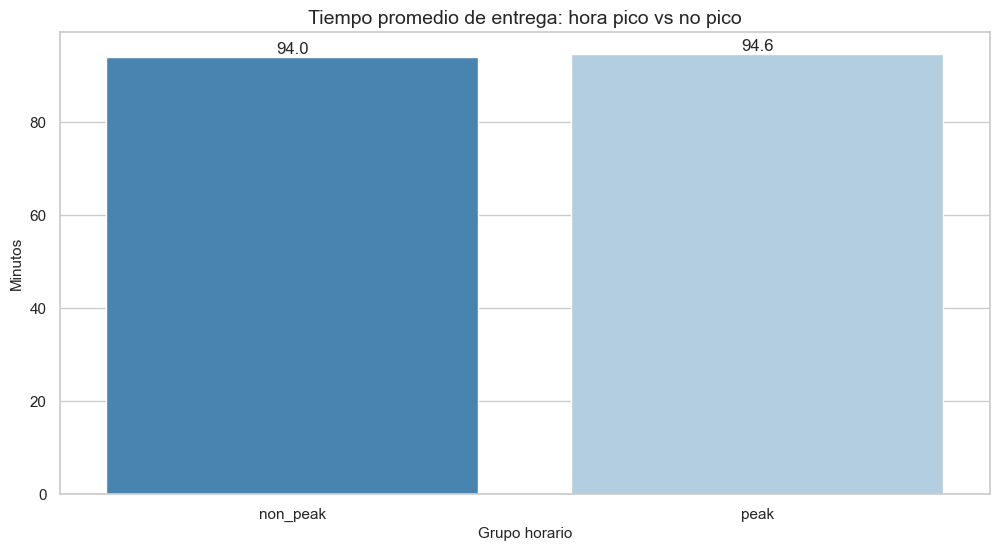

In [7]:
fig, ax = plt.subplots()
sns.barplot(data=peak_df, x='hour_group', y='avg_delivery_time', palette='Blues_r', ax=ax)
ax.set_title('Tiempo promedio de entrega: hora pico vs no pico')
ax.set_xlabel('Grupo horario')
ax.set_ylabel('Minutos')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.show()

## 5. Hipótesis 2: tráfico y clima vs costo de operación

**H0:** el costo de entrega no cambia significativamente con tráfico y clima.

**H1:** el costo de entrega aumenta con tráfico y clima severo.

Esta hipótesis evalúa si el pricing y la logística responden a la complejidad operativa.

In [8]:
conditions_df = run_query("""
SELECT
  traffic_level_score,
  weather_severity_score,
  delivery_fee
FROM fact_delivery_orders f
JOIN dim_delivery_conditions c ON f.delivery_conditions_id = c.delivery_conditions_id
""")
conditions_df['risk_bucket'] = pd.cut(
    conditions_df['traffic_level_score'].fillna(0) + conditions_df['weather_severity_score'].fillna(0),
    bins=[-np.inf, 6, 10, 14, np.inf],
    labels=['bajo', 'medio', 'alto', 'muy_alto']
)
risk_summary = conditions_df.groupby('risk_bucket', observed=True)['delivery_fee'].mean().reset_index()
risk_summary

,risk_bucket,delivery_fee
0,bajo,7.577453
1,medio,7.379408
2,alto,7.523630
3,muy_alto,7.559441


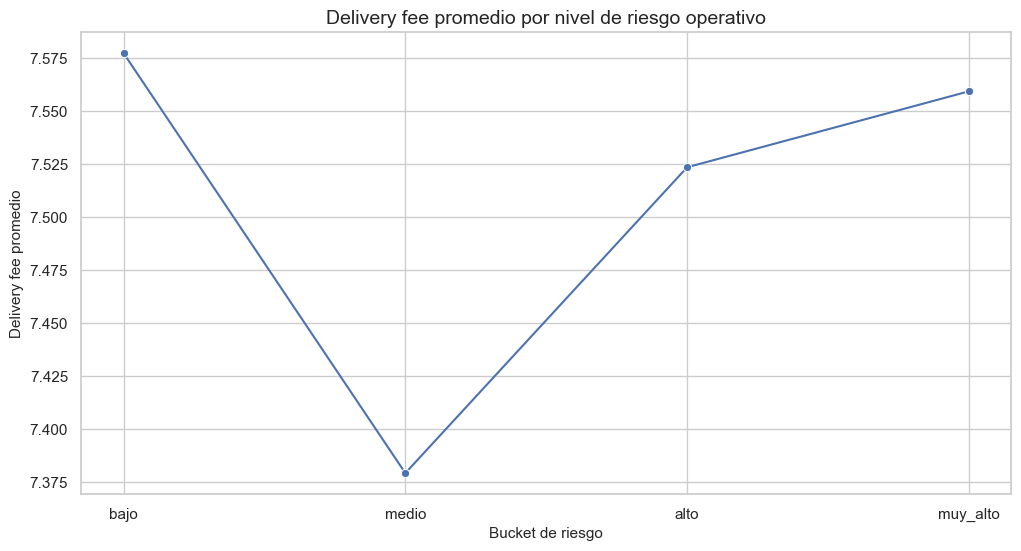

In [9]:
fig, ax = plt.subplots()
sns.lineplot(data=risk_summary, x='risk_bucket', y='delivery_fee', marker='o', ax=ax)
ax.set_title('Delivery fee promedio por nivel de riesgo operativo')
ax.set_xlabel('Bucket de riesgo')
ax.set_ylabel('Delivery fee promedio')
plt.show()

## 6. Hipótesis 3: clientes premium vs satisfacción

**H0:** los clientes premium y no premium tienen el mismo rating promedio.

**H1:** los clientes premium tienen un rating promedio mayor.

Aquí se verifica si el segmento premium realmente aporta una mejor experiencia.

In [10]:
premium_df = run_query("""
SELECT
  CASE WHEN premium_customer_flag = 1 THEN 'premium' ELSE 'non_premium' END AS customer_type,
  AVG(customer_rating) AS avg_rating,
  COUNT(*) AS orders
FROM fact_delivery_orders f
JOIN dim_customer_segment c ON f.customer_segment_id = c.customer_segment_id
GROUP BY 1
""")
premium_df

,customer_type,avg_rating,orders
0,non_premium,3.990648,10779
1,premium,4.002606,4221


C:\Users\usuario\AppData\Local\Temp\ipykernel_17052\1729897550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=premium_df, x='customer_type', y='avg_rating', palette='Greens_r', ax=ax)


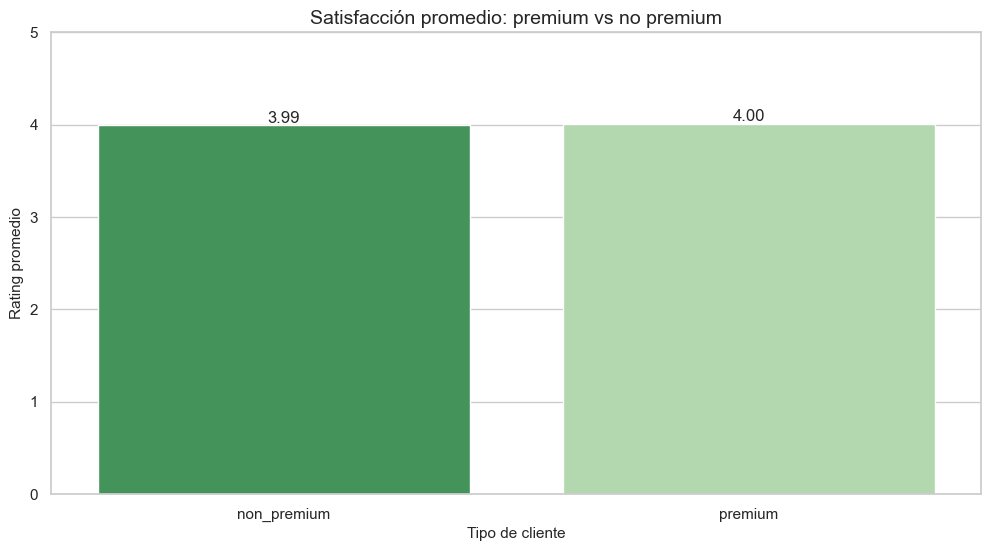

In [11]:
fig, ax = plt.subplots()
sns.barplot(data=premium_df, x='customer_type', y='avg_rating', palette='Greens_r', ax=ax)
ax.set_title('Satisfacción promedio: premium vs no premium')
ax.set_xlabel('Tipo de cliente')
ax.set_ylabel('Rating promedio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.ylim(0, 5)
plt.show()

## 7. Hipótesis 4: descuentos vs cancelación

**H0:** la tasa de cancelación es independiente del uso de descuentos.

**H1:** los pedidos con descuento cancelan menos.

Esta hipótesis ayuda a validar si la promoción realmente reduce fricción comercial.

In [12]:
discount_df = run_query("""
SELECT
  CASE WHEN f.discount_amount > 0 THEN 'con_descuento' ELSE 'sin_descuento' END AS discount_group,
  100.0 * AVG(CASE WHEN o.cancellation_flag = 1 THEN 1 ELSE 0 END) AS cancellation_rate
FROM fact_delivery_orders f
JOIN dim_order_status o ON f.order_status_id = o.order_status_id
GROUP BY 1
""")
discount_df

,discount_group,cancellation_rate
0,con_descuento,13.353333


C:\Users\usuario\AppData\Local\Temp\ipykernel_17052\3872038531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_df, x='discount_group', y='cancellation_rate', palette='Oranges_r', ax=ax)


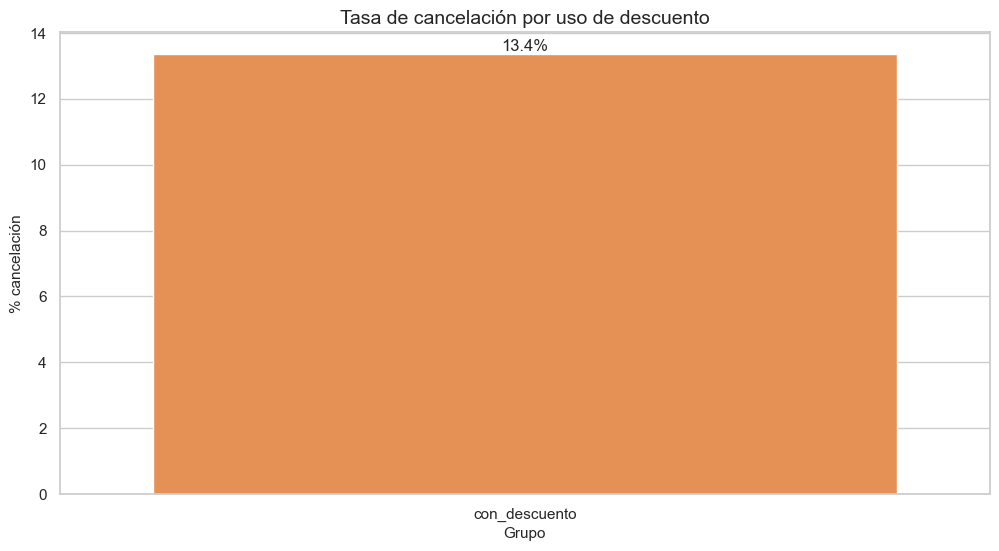

In [13]:
fig, ax = plt.subplots()
sns.barplot(data=discount_df, x='discount_group', y='cancellation_rate', palette='Oranges_r', ax=ax)
ax.set_title('Tasa de cancelación por uso de descuento')
ax.set_xlabel('Grupo')
ax.set_ylabel('% cancelación')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

## 8. Dataset preparado para Power BI

Power BI funciona mejor con tablas agregadas y medidas claras. Abajo quedan algunas vistas que puedes exportar a CSV o usar como base de relaciones.

In [15]:
monthly_kpis = run_query("""
SELECT
  CAST(d.month AS INT) month,
  COUNT(*) AS total_orders,
  AVG(f.delivery_time_minutes) AS avg_delivery_time,
  AVG(f.customer_rating) AS avg_rating,
  100.0 * AVG(CASE WHEN o.cancellation_flag = 1 THEN 1 ELSE 0 END) AS cancellation_rate,
  SUM(f.final_amount_paid) AS total_revenue
FROM fact_delivery_orders f
JOIN dim_date d ON f.date_id = d.date_id
JOIN dim_order_status o ON f.order_status_id = o.order_status_id
GROUP BY d.month
ORDER BY d.month
""")
monthly_kpis

,month,total_orders,avg_delivery_time,avg_rating,cancellation_rate,total_revenue
0,1,1289,94.388673,3.977812,14.352211,152546.550613
1,2,1257,95.894988,3.988226,13.762928,148716.909046
2,3,1270,94.001575,4.009055,13.858268,149667.766975
3,4,1210,93.532231,4.019917,13.223140,143832.558863
4,5,1242,93.599034,3.984138,13.043478,147853.728712
5,6,1230,93.367480,3.984146,12.195122,146104.171734
6,7,1266,93.770142,3.995182,13.586098,148291.659353
7,8,1295,92.369884,4.000695,14.440154,154473.373611
8,9,1255,92.716335,3.971793,13.147410,147857.405272
9,10,1237,94.401778,4.006144,12.449475,145914.136301


In [16]:
export_dir = BASE_DIR / 'data' / 'bi'
export_dir.mkdir(parents=True, exist_ok=True)
monthly_kpis.to_csv(export_dir / 'powerbi_monthly_kpis.csv', index=False)
peak_df.to_csv(export_dir / 'powerbi_peak_hour_summary.csv', index=False)
premium_df.to_csv(export_dir / 'powerbi_premium_summary.csv', index=False)
discount_df.to_csv(export_dir / 'powerbi_discount_summary.csv', index=False)
risk_summary.to_csv(export_dir / 'powerbi_risk_summary.csv', index=False)
str(export_dir)

'c:\\Users\\usuario\\Documents\\01_Principales\\Trabajo\\Universidad\\AnalisisDatos\\food-delivery\\data\\bi'